# Feature Engineering Base

**目的**: RV Butterfly モデルのベースライン性能を確認し、次の特徴量実験の方向性を探る。

## 使い方（Gemini 向け）

1. **このノートブックは変更しない** — ベースライン IC の真実源として保持する  
2. 新しい実験は `designs/pending/` に設計書を作成 → 独立ノートブックで実装  
3. 実験ノートブックの **Cell 1** で必ず `ic_all` と `cs_ic` を再現してから差分を比較する  

## ベースライン IC（RV Butterfly, 2026-03-21 計測）

| Horizon | Global IC | CS IC | Train IC | Gap |
|---------|-----------|-------|----------|-----|
| 3d | 0.373 | **0.304** | 0.521 | 0.148 |
| 5d | 0.418 | **0.346** | 0.573 | 0.154 |

**採用基準**: CS IC が +0.01 以上改善 かつ全フォールドで安定

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import spearmanr

from src.processing        import load_and_clean_data, load_meeting_dates
from src.features_rv       import generate_rv_features
from src.pooling_butterfly import pool_butterfly_data
from src.modeling          import walk_forward_with_model, summarize_ic, get_features_and_target

START_DATE = '2024-01-01'
FOLD_DIAG_START = 5
FLY_SHORT = {2: 'B2', 3: 'B3', 4: 'B4', 5: 'B5', 6: 'B6', 7: 'B7'}

print('Loading data...')
df_raw = load_and_clean_data('../data/BOJ_data.xlsx', '../data/BOJ_meeting_history.csv')
df_rv  = generate_rv_features(df_raw)
df_fly = pool_butterfly_data(df_rv)

print(f'Data: {df_raw["Date"].min().date()} → {df_raw["Date"].max().date()}  |  Pooled shape: {df_fly.shape}')

Loading data...


Data: 2007-03-05 → 2026-03-13  |  Pooled shape: (27918, 36)


## 1. ベースライン IC の再現

新しい実験ノートブックでは必ずこのセルと同一の結果を Cell 1 で確認してから実験を始める。

**現行ベースライン（Model B: post-MPM 5日間除外なし、2026-03-23更新）**

| Horizon | Global IC | CS IC | Train IC | Gap |
|---------|-----------|-------|----------|-----|
| 3d | 0.378 | **0.296** | 0.509 | 0.132 |
| 5d | 0.434 | **0.355** | 0.564 | 0.130 |

採用基準: CS IC が **+0.01 以上改善** かつ全フォールドで安定。


In [2]:
print('Running walk-forward...')
res_3d, mdl_3d, X_test_3d, y_test_3d, X_train_3d = walk_forward_with_model(
    df_fly, 'Target_3d_norm', START_DATE)
res_5d, mdl_5d, X_test_5d, y_test_5d, X_train_5d = walk_forward_with_model(
    df_fly, 'Target_5d_norm', START_DATE)

# std + Days_to_MPM + is_post_mpm を結合（Section 8 以降の分析で使用）
meta_df = (df_fly[['Date', 'Meeting_Index', 'Target_3d_std', 'Target_5d_std',
                    'Days_to_MPM', 'is_post_mpm']]
           .drop_duplicates())
res_3d = res_3d.merge(meta_df, on=['Date', 'Meeting_Index'], how='left')
res_5d = res_5d.merge(meta_df, on=['Date', 'Meeting_Index'], how='left')

ic3 = summarize_ic(res_3d, instrument_indices=set(range(2, 8)))
ic5 = summarize_ic(res_5d, instrument_indices=set(range(2, 8)))

print('\n=== Baseline IC (RV Butterfly, Model B: post-MPM included) ===')
print(f'               3d        5d')
print(f'Global IC  : {ic3["ic_all"]:>8.4f}  {ic5["ic_all"]:>8.4f}')
print(f'CS IC      : {ic3["cs_ic"]:>8.4f}  {ic5["cs_ic"]:>8.4f}   <- 主指標')
print(f'TS IC      : {ic3["ts_ic"]:>8.4f}  {ic5["ts_ic"]:>8.4f}')
print(f'Train IC   : {ic3["train_ic"]:>8.4f}  {ic5["train_ic"]:>8.4f}')
print(f'Gap        : {ic3["gap"]:>8.4f}  {ic5["gap"]:>8.4f}')
print(f'\nFolds: {res_3d["Fold"].nunique()}  |  OOS: {res_3d["Date"].min().date()} -> {res_3d["Date"].max().date()}')


Running walk-forward...



=== Baseline IC (RV Butterfly, Model B: post-MPM included) ===
               3d        5d
Global IC  :   0.3777    0.4342
CS IC      :   0.2963    0.3550   <- 主指標
TS IC      :   0.3859    0.4432
Train IC   :   0.5093    0.5641
Gap        :   0.1316    0.1299

Folds: 9  |  OOS: 2024-01-04 -> 2026-03-10


## 2. Fold 別 Global IC

どのフォールドが強い/弱いかを把握する。時系列的なドリフトや分布シフトの診断に使う。

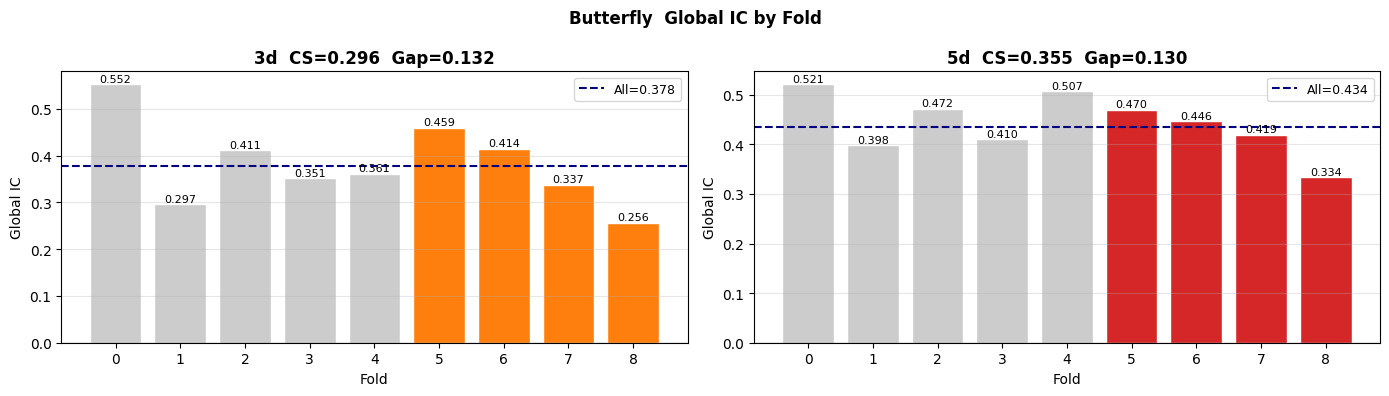

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Butterfly  Global IC by Fold', fontsize=12, fontweight='bold')

for ax, ic_dict, title, color_hi in [
        (axes[0], ic3, '3d', '#ff7f0e'),
        (axes[1], ic5, '5d', '#d62728')]:
    folds = sorted(ic_dict['ic_by_fold'].keys())
    vals  = [ic_dict['ic_by_fold'][f] for f in folds]
    colors = [color_hi if f >= FOLD_DIAG_START else '#cccccc' for f in folds]
    ax.bar([str(f) for f in folds], vals, color=colors, edgecolor='white')
    ax.axhline(ic_dict['ic_all'], color='navy', lw=1.5, ls='--', label=f'All={ic_dict["ic_all"]:.3f}')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'{title}  CS={ic_dict["cs_ic"]:.3f}  Gap={ic_dict["gap"]:.3f}', fontweight='bold')
    ax.set_xlabel('Fold');  ax.set_ylabel('Global IC')
    ax.legend(fontsize=9);  ax.grid(True, axis='y', alpha=0.3)
    for i, v in enumerate(vals):
        ax.text(i, v + (0.005 if v >= 0 else -0.018), f'{v:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

## 3. 銘柄別 IC（B2–B7）

どのバタフライが予測しやすく、どれが難しいかを把握する。  
IC が低い銘柄は固有の特徴量が必要な可能性がある。

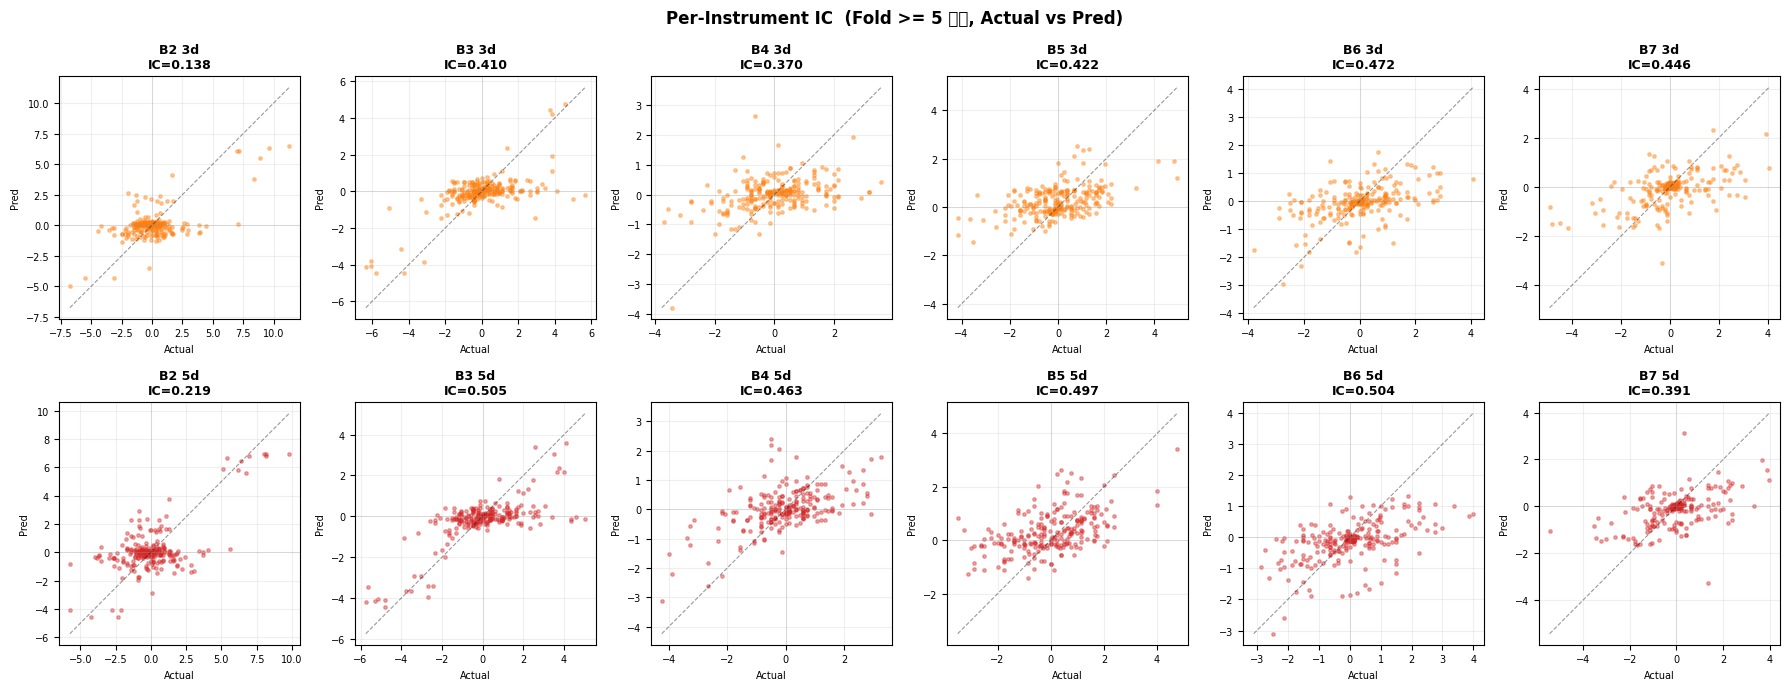

In [4]:
fig, axes = plt.subplots(2, 6, figsize=(18, 7))
fig.suptitle('Per-Instrument IC  (Fold >= 5 のみ, Actual vs Pred)', fontsize=12, fontweight='bold')

for row_i, (res, title, color) in enumerate([
        (res_3d, '3d', '#ff7f0e'), (res_5d, '5d', '#d62728')]):
    sub = res[res['Fold'] >= FOLD_DIAG_START]
    for col_i, n in enumerate(range(2, 8)):
        ax = axes[row_i, col_i]
        g  = sub[sub['Meeting_Index'] == n]
        if g.empty:
            ax.set_visible(False); continue
        ic, _ = spearmanr(g['Actual'], g['Pred'])
        ax.scatter(g['Actual'], g['Pred'], s=6, alpha=0.4, color=color)
        lo = min(g['Actual'].min(), g['Pred'].min())
        hi = max(g['Actual'].max(), g['Pred'].max())
        ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.4)
        ax.axhline(0, color='gray', lw=0.5, alpha=0.3)
        ax.axvline(0, color='gray', lw=0.5, alpha=0.3)
        ax.set_title(f'{FLY_SHORT[n]} {title}\nIC={ic:.3f}', fontsize=9, fontweight='bold')
        ax.set_xlabel('Actual', fontsize=7); ax.set_ylabel('Pred', fontsize=7)
        ax.tick_params(labelsize=7); ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## 4. 特徴量重要度（最終フォールド）

どの特徴量がモデルに貢献しているかを確認する。  
Gain が低い特徴量は削除候補、上位が固まっているなら飽和の可能性がある。

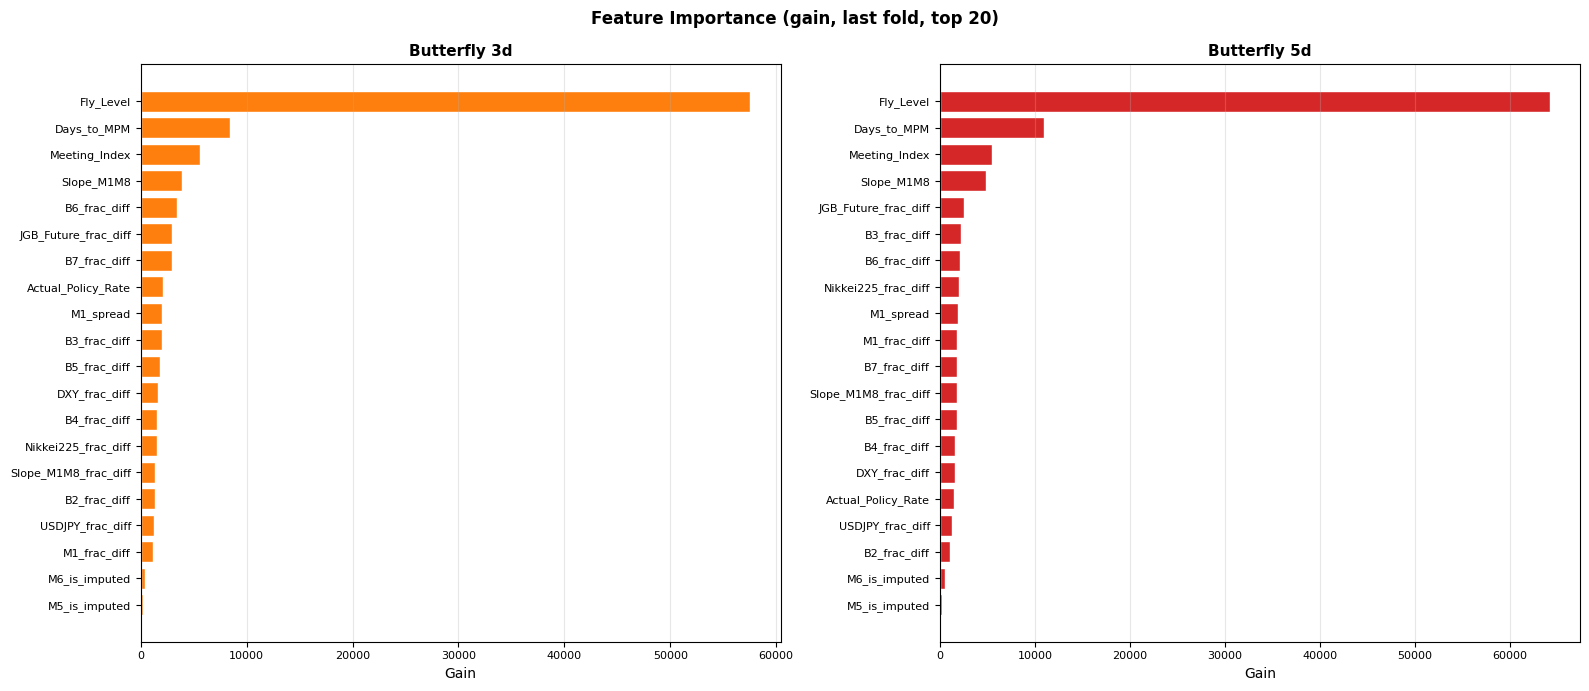

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Feature Importance (gain, last fold, top 20)', fontsize=12, fontweight='bold')

for ax, model, title, color in [
        (axes[0], mdl_3d, 'Butterfly 3d', '#ff7f0e'),
        (axes[1], mdl_5d, 'Butterfly 5d', '#d62728')]:
    imp = pd.DataFrame({'feature': model.feature_name(),
                        'gain':    model.feature_importance(importance_type='gain')})
    imp = imp.sort_values('gain', ascending=False).head(20)
    ax.barh(imp['feature'][::-1], imp['gain'][::-1], color=color, edgecolor='white')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Gain'); ax.tick_params(labelsize=8); ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. 残差分析

モデルが「いつ」「どんな状況で」外れるかを分析する。  
新しい特徴量のヒントが見つかることが多い。

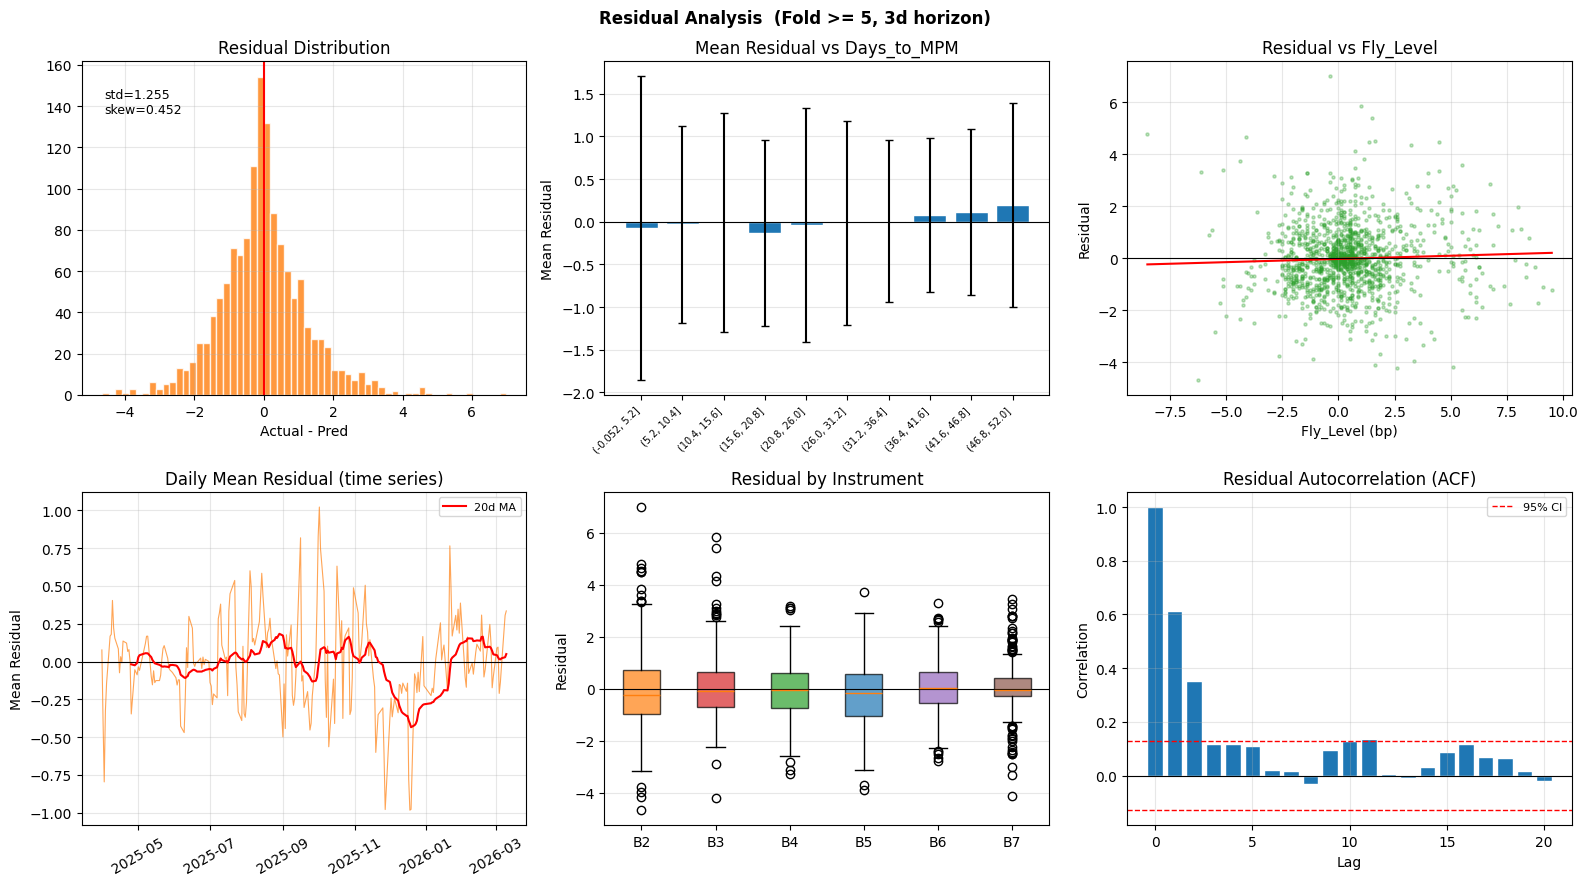

In [6]:
# Fold5+ のみで残差を計算
sub3 = res_3d[res_3d['Fold'] >= FOLD_DIAG_START].copy()
sub3['Residual'] = sub3['Actual'] - sub3['Pred']

# Days_to_MPM と Fly_Level を結合
meta = df_fly[['Date', 'Meeting_Index', 'Fly_Level']].drop_duplicates()
sub3 = sub3.merge(meta, on=['Date', 'Meeting_Index'], how='left')
sub3['Fly_Level_bp'] = sub3['Fly_Level'] * 100

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Residual Analysis  (Fold >= 5, 3d horizon)', fontsize=12, fontweight='bold')

# (0,0) 残差の分布
ax = axes[0, 0]
ax.hist(sub3['Residual'], bins=60, color='#ff7f0e', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', lw=1.5)
ax.set_title('Residual Distribution'); ax.set_xlabel('Actual - Pred')
ax.text(0.05, 0.92, f'std={sub3["Residual"].std():.3f}\nskew={sub3["Residual"].skew():.3f}',
        transform=ax.transAxes, fontsize=9, va='top')
ax.grid(True, alpha=0.3)

# (0,1) 残差 vs Days_to_MPM（ビン集計）
ax = axes[0, 1]
sub3['DtM_bin'] = pd.cut(sub3['Days_to_MPM'], bins=10)
grp = sub3.groupby('DtM_bin')['Residual'].agg(['mean', 'std']).reset_index()
ax.bar(range(len(grp)), grp['mean'], color='#1f77b4', edgecolor='white')
ax.errorbar(range(len(grp)), grp['mean'], yerr=grp['std'], fmt='none', color='black', capsize=3)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(range(len(grp)))
ax.set_xticklabels([str(b) for b in grp['DtM_bin']], rotation=45, ha='right', fontsize=7)
ax.set_title('Mean Residual vs Days_to_MPM'); ax.set_ylabel('Mean Residual')
ax.grid(True, axis='y', alpha=0.3)

# (0,2) 残差 vs Fly_Level（散布図）
ax = axes[0, 2]
ax.scatter(sub3['Fly_Level_bp'], sub3['Residual'], s=5, alpha=0.3, color='#2ca02c')
z = np.polyfit(sub3['Fly_Level_bp'].dropna(), sub3.loc[sub3['Fly_Level_bp'].notna(), 'Residual'], 1)
x_line = np.linspace(sub3['Fly_Level_bp'].min(), sub3['Fly_Level_bp'].max(), 100)
ax.plot(x_line, np.polyval(z, x_line), 'r-', lw=1.5)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Residual vs Fly_Level'); ax.set_xlabel('Fly_Level (bp)'); ax.set_ylabel('Residual')
ax.grid(True, alpha=0.3)

# (1,0) 残差の時系列
ax = axes[1, 0]
daily_res = sub3.groupby('Date')['Residual'].mean().reset_index()
ax.plot(daily_res['Date'], daily_res['Residual'], lw=0.8, color='#ff7f0e', alpha=0.7)
ax.axhline(0, color='black', lw=0.8)
daily_res['MA20'] = daily_res['Residual'].rolling(20).mean()
ax.plot(daily_res['Date'], daily_res['MA20'], 'r-', lw=1.5, label='20d MA')
ax.set_title('Daily Mean Residual (time series)'); ax.set_ylabel('Mean Residual')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=30)

# (1,1) 銘柄別 残差の箱ひげ
ax = axes[1, 1]
labels = [FLY_SHORT[n] for n in range(2, 8)]
data   = [sub3.loc[sub3['Meeting_Index'] == n, 'Residual'].values for n in range(2, 8)]
bp = ax.boxplot(data, labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'],
        ['#ff7f0e', '#d62728', '#2ca02c', '#1f77b4', '#9467bd', '#8c564b']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Residual by Instrument'); ax.set_ylabel('Residual')
ax.grid(True, axis='y', alpha=0.3)

# (1,2) 残差の自己相関（ラグ 1-20）
ax = axes[1, 2]
resid_series = daily_res['Residual'].dropna().values
max_lag = 20
acf_vals = [np.corrcoef(resid_series[:-lag], resid_series[lag:])[0, 1]
            if lag > 0 else 1.0 for lag in range(max_lag + 1)]
conf = 1.96 / np.sqrt(len(resid_series))
ax.bar(range(max_lag + 1), acf_vals, color='#1f77b4', edgecolor='white')
ax.axhline(conf,  color='red', ls='--', lw=1, label='95% CI')
ax.axhline(-conf, color='red', ls='--', lw=1)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Residual Autocorrelation (ACF)'); ax.set_xlabel('Lag'); ax.set_ylabel('Correlation')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. 特徴量の目的変数との単変量相関

各特徴量と Target の Spearman IC を単独で計算する。  
現在の特徴量セットで説明できていない部分（IC が低い or 未使用の変数）が FE のヒントになる。

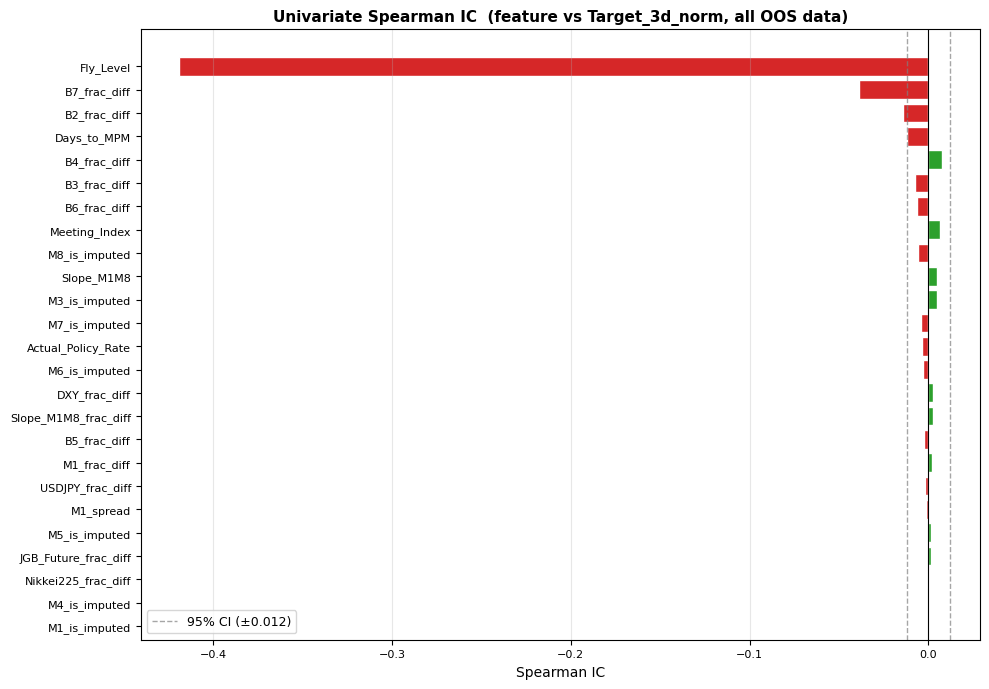


Top 10 univariate IC:
      feature        IC      p_value
    Fly_Level -0.419078 0.000000e+00
 B7_frac_diff -0.038683 1.282057e-10
 B2_frac_diff -0.013942 2.053139e-02
  Days_to_MPM -0.012017 4.585833e-02
 B4_frac_diff  0.007512 2.120011e-01
 B3_frac_diff -0.007350 2.220022e-01
 B6_frac_diff -0.006573 2.748002e-01
Meeting_Index  0.006355 2.910475e-01
M8_is_imputed -0.005764 3.382121e-01
   Slope_M1M8  0.005053 4.011717e-01


In [7]:
# 全期間データで特徴量と Target_3d_norm の単変量 Spearman IC を計算
X, y, dates, m_idx = get_features_and_target(df_fly, 'Target_3d_norm')

uni_ics = []
for col in X.columns:
    valid = X[col].notna() & y.notna()
    if valid.sum() < 30:
        continue
    ic, pval = spearmanr(X.loc[valid, col], y[valid])
    uni_ics.append({'feature': col, 'IC': ic, 'abs_IC': abs(ic), 'p_value': pval})

uni_df = pd.DataFrame(uni_ics).sort_values('abs_IC', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#2ca02c' if v > 0 else '#d62728' for v in uni_df['IC']]
ax.barh(uni_df['feature'][::-1], uni_df['IC'][::-1], color=colors[::-1], edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
conf = 1.96 / np.sqrt(X.shape[0])
ax.axvline(conf,  color='gray', lw=1, ls='--', alpha=0.7, label=f'95% CI (±{conf:.3f})')
ax.axvline(-conf, color='gray', lw=1, ls='--', alpha=0.7)
ax.set_title('Univariate Spearman IC  (feature vs Target_3d_norm, all OOS data)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Spearman IC'); ax.legend(fontsize=9); ax.grid(True, axis='x', alpha=0.3)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

print('\nTop 10 univariate IC:')
print(uni_df[['feature', 'IC', 'p_value']].head(10).to_string(index=False))

## 7. 特徴量間の相関ヒートマップ

高い相関を持つ特徴量ペアを可視化する。  
相関が高い特徴量は冗長なので、一方を新しい情報に置き換える実験が有効。

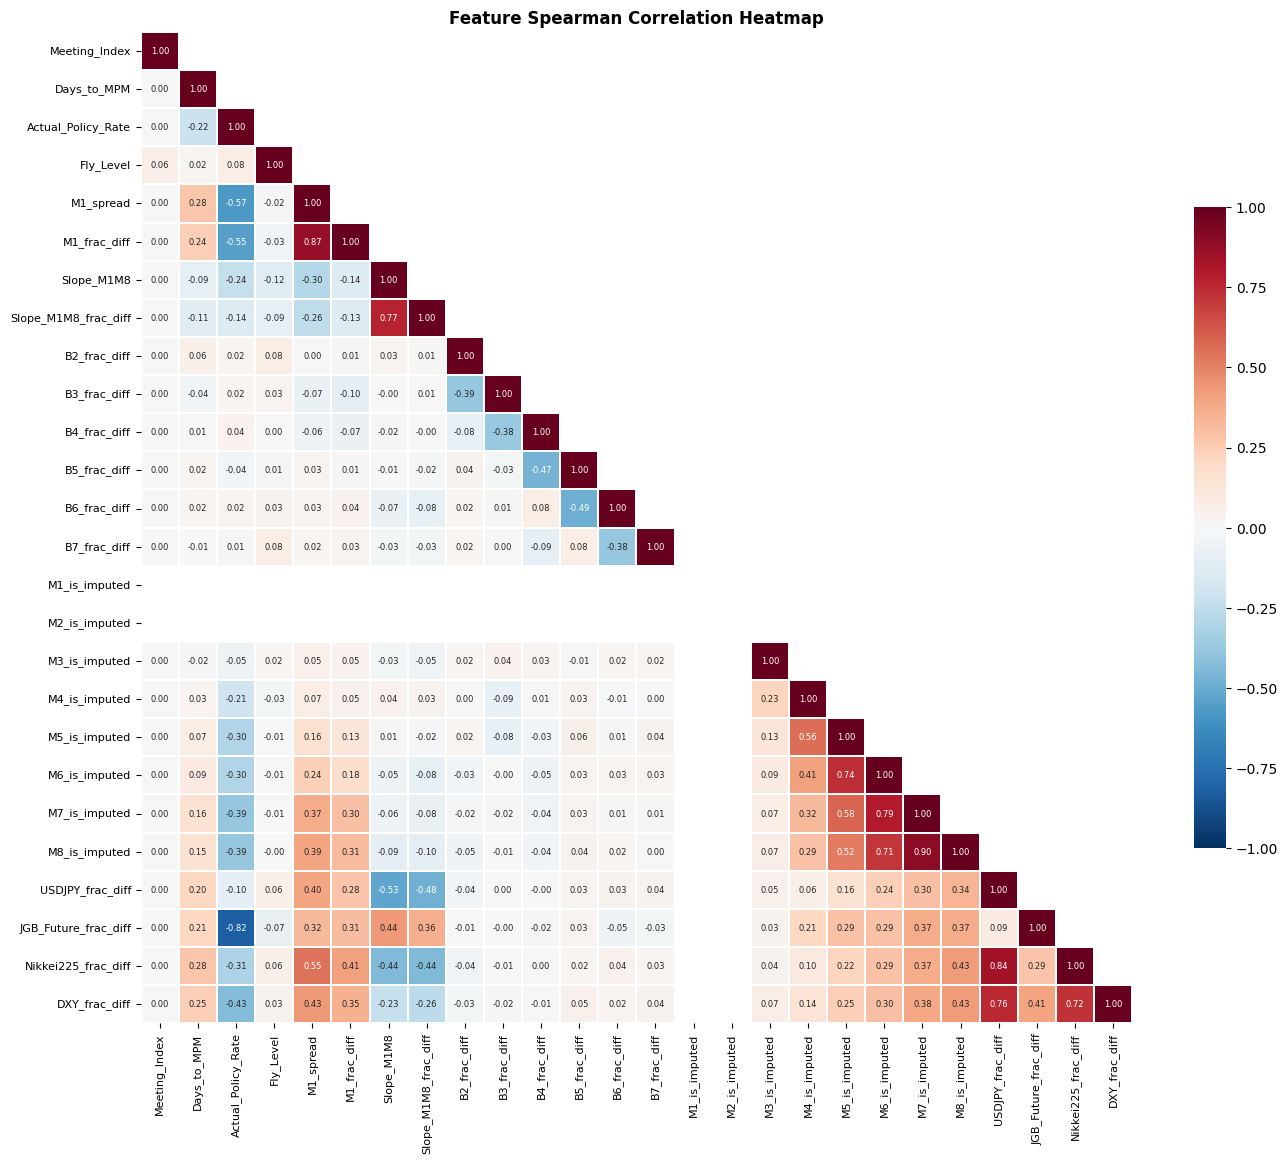

In [8]:
corr_mat = X.corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)  # 上三角を非表示
sns.heatmap(corr_mat, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.3,
            annot=True, fmt='.2f', annot_kws={'size': 6},
            ax=ax, cbar_kws={'shrink': 0.6})
ax.set_title('Feature Spearman Correlation Heatmap', fontsize=12, fontweight='bold')
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

## 8. Days_to_MPM 別・Post-MPM 別の予測精度

MPM が近い日と遠い日で IC がどう変わるかを確認する。  
また post-MPM 5日間（D+0〜D+5）の日別 IC も可視化する。  
Model B では post-MPM も訓練・テストに含まれるため、この分析が意味を持つ。


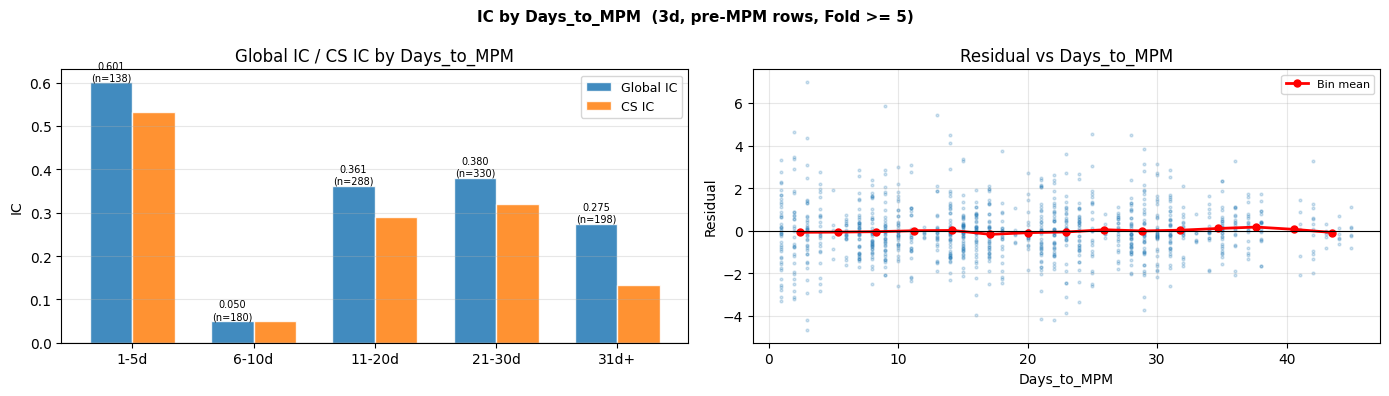

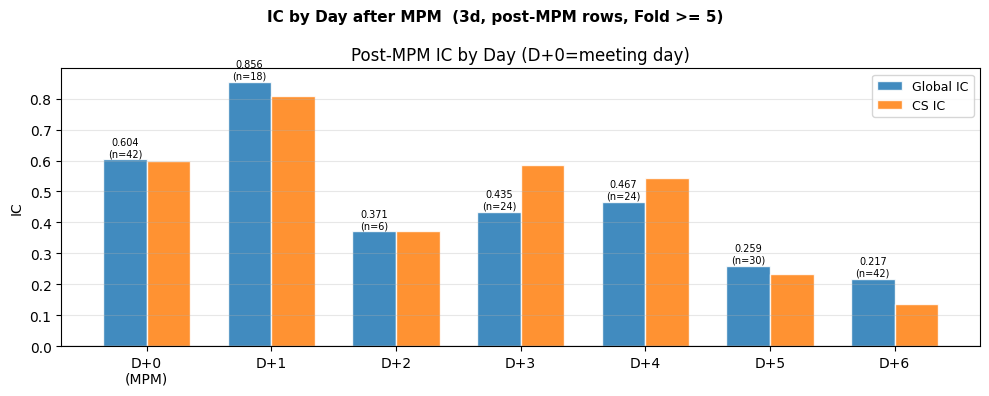


[ Post-MPM IC breakdown (3d, Fold >= 5) ]
  Day       Global IC    CS IC     n
  D+0 (MPM)     +0.604   +0.600    42
  D+1          +0.856   +0.810    18
  D+2          +0.371   +0.371     6
  D+3          +0.435   +0.586    24
  D+4          +0.467   +0.543    24
  D+5          +0.259   +0.234    30
  D+6          +0.217   +0.135    42
  Post total     +0.423   +0.367   252


In [9]:
import bisect

# ── 8a. Days_to_MPM 別 IC（pre-MPM rows のみ）────────────────────────────
sub3 = res_3d[res_3d['Fold'] >= FOLD_DIAG_START].copy()
sub3['Residual'] = sub3['Actual'] - sub3['Pred']

pre3 = sub3[sub3['is_post_mpm'] == 0].copy()
pre3['DtM_bin'] = pd.cut(pre3['Days_to_MPM'],
                          bins=[-1, 5, 10, 20, 30, 200],
                          labels=['1-5d', '6-10d', '11-20d', '21-30d', '31d+'])

ic_by_dtm = []
for grp_name, grp_df in pre3.groupby('DtM_bin', observed=True):
    if len(grp_df) < 10:
        continue
    ic_g, _ = spearmanr(grp_df['Actual'], grp_df['Pred'])
    cs = []
    for _, g in grp_df.groupby('Date'):
        if len(g) >= 3:
            v, _ = spearmanr(g['Actual'], g['Pred'])
            if not np.isnan(v): cs.append(v)
    ic_cs = np.mean(cs) if cs else np.nan
    ic_by_dtm.append({'DtM': str(grp_name), 'Global IC': ic_g, 'CS IC': ic_cs, 'n': len(grp_df)})
dtm_df = pd.DataFrame(ic_by_dtm)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('IC by Days_to_MPM  (3d, pre-MPM rows, Fold >= 5)', fontsize=11, fontweight='bold')
x = np.arange(len(dtm_df)); w = 0.35
ax = axes[0]
ax.bar(x - w/2, dtm_df['Global IC'], w, label='Global IC', color='#1f77b4', alpha=0.85, edgecolor='white')
ax.bar(x + w/2, dtm_df['CS IC'],     w, label='CS IC',     color='#ff7f0e', alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(dtm_df['DtM'])
ax.set_title('Global IC / CS IC by Days_to_MPM'); ax.set_ylabel('IC')
ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3)
for i, row in dtm_df.iterrows():
    ax.text(i - w/2, row['Global IC'] + (0.005 if row['Global IC'] >= 0 else -0.015),
            f'{row["Global IC"]:.3f}\n(n={row["n"]})', ha='center', fontsize=7)

ax = axes[1]
ax.scatter(pre3['Days_to_MPM'], pre3['Residual'], s=4, alpha=0.2, color='#1f77b4')
bins_dtm = pd.cut(pre3['Days_to_MPM'], bins=15)
grp_mean = pre3.groupby(bins_dtm, observed=True)['Residual'].mean()
mid_pts  = [iv.mid for iv in grp_mean.index]
ax.plot(mid_pts, grp_mean.values, 'r-o', lw=2, markersize=5, label='Bin mean')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Residual vs Days_to_MPM')
ax.set_xlabel('Days_to_MPM'); ax.set_ylabel('Residual')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── 8b. Post-MPM D+0〜D+5 別 IC ──────────────────────────────────────────
meeting_dates_list = sorted(df_raw[df_raw['Is_Meeting_Day'] == 1]['Date'].unique())

def days_after_mpm(d):
    idx = bisect.bisect_right(meeting_dates_list, d) - 1
    return (d - meeting_dates_list[idx]).days if idx >= 0 else np.nan

post3 = sub3[sub3['is_post_mpm'] == 1].copy()
post3['D_after'] = post3['Date'].map(days_after_mpm)

post_ic = []
for d in range(0, 7):
    s = post3[post3['D_after'] == d]
    if len(s) < 3:
        continue
    ig, _ = spearmanr(s['Actual'], s['Pred'])
    cs = []
    for _, g in s.groupby('Date'):
        if len(g) >= 3:
            v, _ = spearmanr(g['Actual'], g['Pred'])
            if not np.isnan(v): cs.append(v)
    ic_cs = np.mean(cs) if cs else np.nan
    lbl = f'D+{d}' if d > 0 else 'D+0\n(MPM)'
    post_ic.append({'Day': lbl, 'Global IC': ig, 'CS IC': ic_cs, 'n': len(s)})
post_df = pd.DataFrame(post_ic)

if not post_df.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    fig.suptitle('IC by Day after MPM  (3d, post-MPM rows, Fold >= 5)', fontsize=11, fontweight='bold')
    xp = np.arange(len(post_df))
    ax.bar(xp - w/2, post_df['Global IC'], w, label='Global IC', color='#1f77b4', alpha=0.85, edgecolor='white')
    ax.bar(xp + w/2, post_df['CS IC'],     w, label='CS IC',     color='#ff7f0e', alpha=0.85, edgecolor='white')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(xp); ax.set_xticklabels(post_df['Day'])
    ax.set_title('Post-MPM IC by Day (D+0=meeting day)'); ax.set_ylabel('IC')
    ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3)
    for i, row in post_df.iterrows():
        ax.text(i - w/2, row['Global IC'] + (0.01 if row['Global IC'] >= 0 else -0.02),
                f'{row["Global IC"]:.3f}\n(n={row["n"]})', ha='center', fontsize=7)
    plt.tight_layout(); plt.show()

# 数値テーブル表示
print('\n[ Post-MPM IC breakdown (3d, Fold >= 5) ]')
print(f"  {'Day':<8}  {'Global IC':>9}  {'CS IC':>7}  {'n':>4}")
for _, row in post_df.iterrows():
    print(f"  {row['Day'].replace(chr(10),' '):<8}  {row['Global IC']:>+9.3f}  {row['CS IC']:>+7.3f}  {int(row['n']):>4}")
# post合計
if not post3.empty:
    ig_all, _ = spearmanr(post3['Actual'], post3['Pred'])
    cs_all = []
    for _, g in post3.groupby('Date'):
        if len(g) >= 3:
            v, _ = spearmanr(g['Actual'], g['Pred'])
            if not np.isnan(v): cs_all.append(v)
    print(f"  {'Post total':<8}  {ig_all:>+9.3f}  {np.mean(cs_all) if cs_all else float('nan'):>+7.3f}  {len(post3):>4}")


## 9. 予測の信頼度別的中率（Quintile 分析）

モデルの予測値の絶対値が大きい（＝確信度が高い）ときに、的中率が上がるかを確認する。  
上がるならシグナルとして使える。上がらないなら過信は禁物。

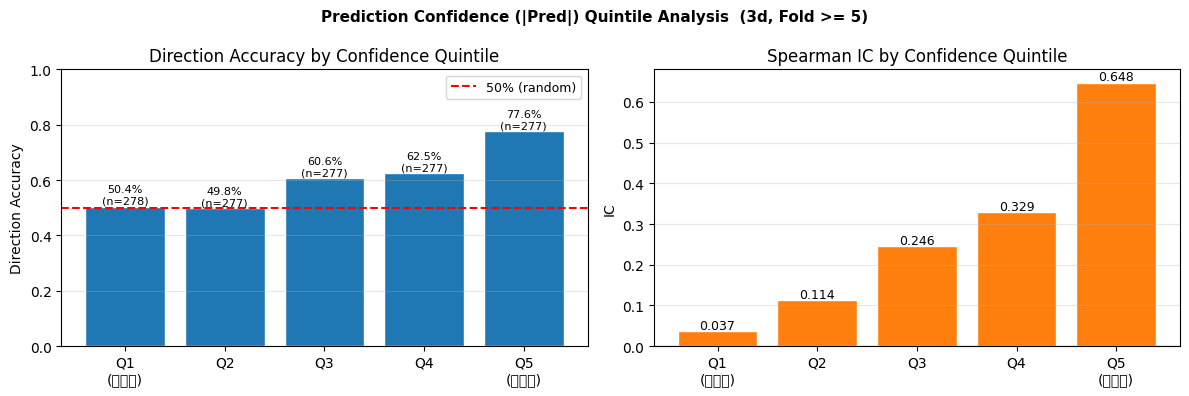

In [10]:
sub3_q = sub3.copy()
sub3_q['AbsPred'] = sub3_q['Pred'].abs()
sub3_q['Correct'] = (np.sign(sub3_q['Actual']) == np.sign(sub3_q['Pred'])).astype(int)
sub3_q['Quintile'] = pd.qcut(sub3_q['AbsPred'], q=5, labels=['Q1\n(低確信)', 'Q2', 'Q3', 'Q4', 'Q5\n(高確信)'])

quint_stats = sub3_q.groupby('Quintile', observed=True).agg(
    Dir_Acc=('Correct', 'mean'),
    IC_in_grp=('Actual', lambda x: spearmanr(x, sub3_q.loc[x.index, 'Pred'])[0]),
    n=('Correct', 'count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Prediction Confidence (|Pred|) Quintile Analysis  (3d, Fold >= 5)',
             fontsize=11, fontweight='bold')

ax = axes[0]
ax.bar(quint_stats['Quintile'].astype(str), quint_stats['Dir_Acc'],
       color='#1f77b4', edgecolor='white')
ax.axhline(0.5, color='red', lw=1.5, ls='--', label='50% (random)')
ax.set_title('Direction Accuracy by Confidence Quintile')
ax.set_ylabel('Direction Accuracy'); ax.set_ylim(0, 1)
ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3)
for i, row in quint_stats.iterrows():
    ax.text(i, row['Dir_Acc'] + 0.01, f'{row["Dir_Acc"]:.1%}\n(n={row["n"]})',
            ha='center', fontsize=8)

ax = axes[1]
ax.bar(quint_stats['Quintile'].astype(str), quint_stats['IC_in_grp'],
       color='#ff7f0e', edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Spearman IC by Confidence Quintile')
ax.set_ylabel('IC'); ax.grid(True, axis='y', alpha=0.3)
for i, row in quint_stats.iterrows():
    ax.text(i, row['IC_in_grp'] + (0.005 if row['IC_in_grp'] >= 0 else -0.02),
            f'{row["IC_in_grp"]:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 10. 分析まとめ・次の実験方針

上記の可視化結果を踏まえて、次に試すべき特徴量候補を整理する。

---

### 観察事項（実行後に記入）

| 観察 | 詳細 | FE への示唆 |
|------|------|-------------|
| Fold別IC | ... | ... |
| 残差 vs Days_to_MPM | ... | タイミング特徴量の有効性 |
| 残差 vs Fly_Level | ... | 水準特徴量の追加 |
| 残差ACF | ... | ラグ特徴量の有効性 |
| 単変量IC | ... | 追加すべき変数 |
| 相関ヒートマップ | ... | 冗長特徴量の削除候補 |
| 信頼度Quintile | ... | シグナル強度の信頼性 |

---

### 次の実験候補（designs/pending/ に設計書を作成する）

| 優先度 | 実験ID | 内容 | 仮説 |
|--------|--------|------|------|
| 高 | ... | ... | ... |
| 中 | ... | ... | ... |

---

### 実験のテンプレート（新しいノートブックの Cell 1）

```python
# ─── Baseline IC 再現（変更禁止）───────────────────────────────────────────
# feature_engineering_base.ipynb の Cell 2 と同一の出力を確認してから実験を始める
# Expected: Global IC 3d≈0.373  CS IC 3d≈0.304
#           Global IC 5d≈0.418  CS IC 5d≈0.346

# ─── Experiment: [実験ID] ────────────────────────────────────────────────
# 変更: [何を変えるか]
# 仮説: [なぜ改善すると思うか]

# ... 実験コード ...

# ─── 評価 ────────────────────────────────────────────────────────────────
ic3_exp = summarize_ic(res_3d_exp, instrument_indices=set(range(2, 8)))
print(f'Delta CS IC 3d: {ic3_exp["cs_ic"] - 0.304:+.4f}  (採用基準: +0.01 以上)')
print(f'Delta CS IC 5d: {ic5_exp["cs_ic"] - 0.346:+.4f}')
```